In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading the dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [5]:
#Counts of job title 

df.pivot_table(values='salary_year_avg', index='job_country', columns='job_title_short', aggfunc='median')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


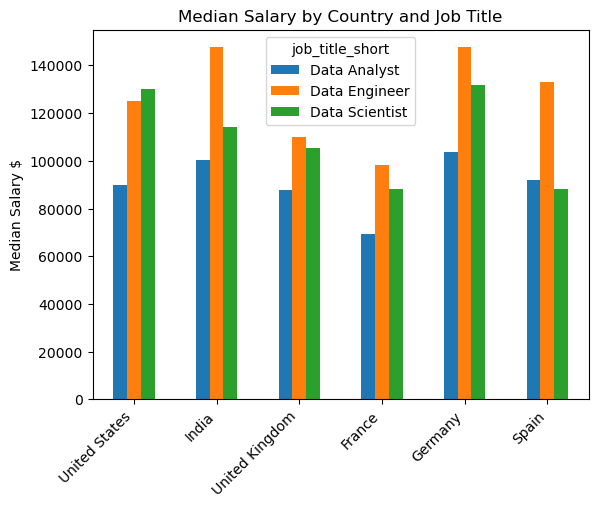

In [19]:
top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df.pivot_table(
    values = 'salary_year_avg',
    index = 'job_country',
    columns= 'job_title_short',
    aggfunc= 'median'
)
df_job_country_salary = df_job_country_salary.loc[top_countries]

job_titles = ['Data Analyst' , 'Data Engineer' , 'Data Scientist']
df_job_country_salary = df_job_country_salary[job_titles]

df_job_country_salary.plot(kind='bar')
plt.ylabel('Median Salary $')
plt.xlabel('')
plt.title('Median Salary by Country and Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
#Count Job Postings by Title and Country
country_sort = df.groupby(['job_title_short', 'job_country']).size().sort_values(ascending=False).head(20)

job_title_short        job_country   
Data Analyst           United States     67816
Data Scientist         United States     58830
Data Engineer          United States     35080
                       India             19062
Data Analyst           France            13803
Data Scientist         India             13279
Senior Data Scientist  United States     12946
Data Engineer          United Kingdom    11807
Senior Data Analyst    United States     11791
Data Engineer          France            10936
Data Analyst           United Kingdom    10482
Data Scientist         France             9497
Senior Data Engineer   United States      9289
Data Scientist         United Kingdom     9148
                       Sudan              8544
Business Analyst       United States      7382
Data Analyst           Germany            7131
Data Scientist         Germany            6745
Data Engineer          Spain              6740
                       Germany            6675
dtype: int64

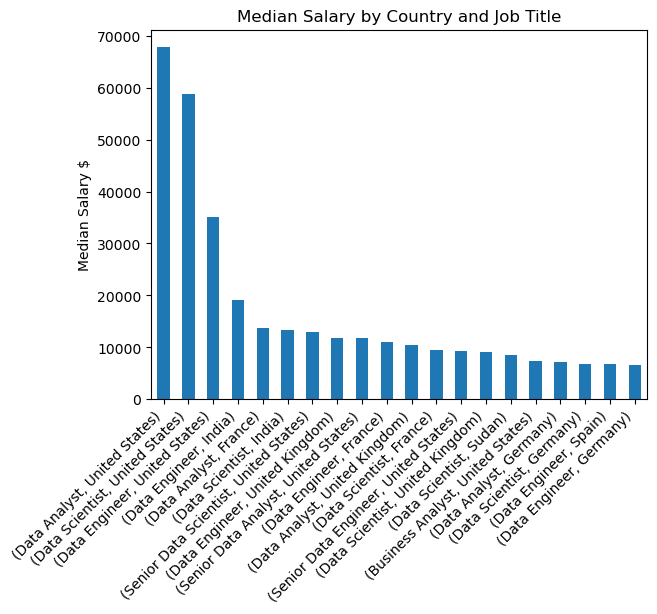

In [24]:
country_sort = df.groupby(['job_title_short', 'job_country']).size().sort_values(ascending=False).head(20)
country_sort.plot(kind='bar')
plt.ylabel('Median Salary $')
plt.xlabel('')
plt.title('Median Salary by Country and Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
#Sum Salary by Title and Country
df.pivot_table(values='salary_year_avg', index='job_country', columns='job_title_short', aggfunc='sum')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Afghanistan,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN
Albania,0.0,0.0,99900.0,0.0,139962.5,0.0,0.0,0.0,157500.0,0.0
Algeria,0.0,0.0,44100.0,45000.0,0.0,0.0,NaN,0.0,NaN,0.0
Angola,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
Argentina,142200.0,197500.0,341745.5,1225599.0,597221.5,393029.0,0.0,295000.0,0.0,174500.0
...,...,...,...,...,...,...,...,...,...,...
Venezuela,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Vietnam,223200.0,0.0,999267.0,1576131.0,534400.0,571050.0,402050.0,508500.0,79200.0,107200.0
Yemen,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0
